In [219]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.special import xlogy
from scipy.stats import norm, chi2
from arch import arch_model
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.diagnostic import acorr_ljungbox 
import yfinance as yf

In [220]:
np.random.seed(42)

In [221]:
def plot_graph(x, title="", label="", xaxis="", yaxis=""):
    plt.plot(x, label=label)
    plt.title(title)
    plt.xlabel(xaxis)
    plt.ylabel(yaxis)
    plt.grid(True)

### 1. Попередня обробка та аналіз

In [222]:
# ticker = "EURUAH=X"
# start = "2016-01-01"
# end = "2026-06-18" 

# price = yf.download(ticker, start=start, end=end, progress=False)["Close"].dropna()

# price = price.rename(columns={"EURUAH=X": "Price"})

# price.to_csv("EURUAH.csv")

In [223]:
data = pd.read_csv("EURUAH.csv")
data

,Date,Price
0,2016-01-01,25.871099
1,2016-01-04,25.871099
2,2016-01-05,25.955900
3,2016-01-06,25.541500
4,2016-01-07,24.800301
...,...,...
2715,2026-06-11,50.526798
2716,2026-06-12,50.289001
2717,2026-06-15,50.333698
2718,2026-06-16,50.524200


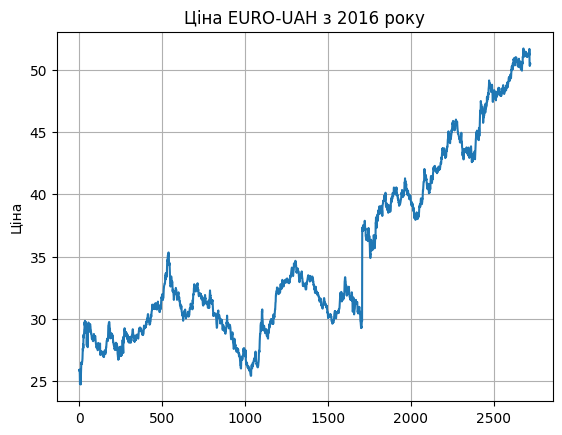

In [224]:
plot_graph(data["Price"], title="Ціна EURO-UAH з 2016 року", yaxis="Ціна")

#### Розрахуйте логарифмічну дохідність золота.

In [225]:
data['returns'] = np.log(data['Price'] / data['Price'].shift(1))

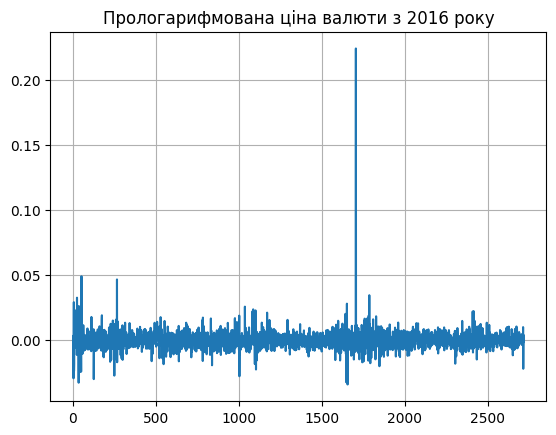

In [226]:
plot_graph(data["returns"], title="Прологарифмована ціна валюти з 2016 року")

In [227]:
data.max()["returns"]

np.float64(0.22425106904076536)

In [228]:
data.idxmax()["returns"]

np.int64(1706)

In [229]:
returns = data['returns'][1:]
x = np.linspace(returns.min(), returns.max(), len(returns))

mu = returns.mean()
sigma = returns.std()
normalized_data_example = norm.pdf(x, mu, sigma)

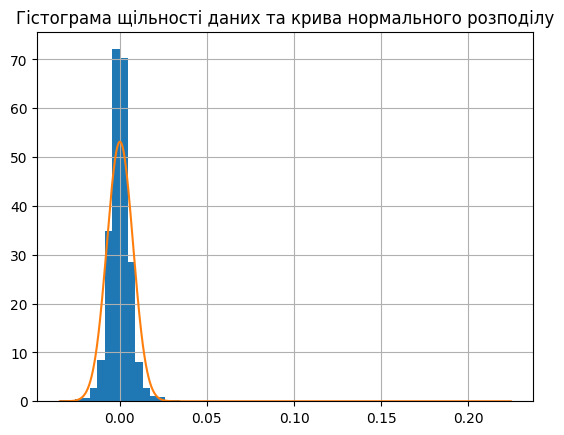

In [230]:
plt.hist(data["returns"], bins=60, density=True)
plt.plot(x, normalized_data_example)
plt.title("Гістограма щільності даних та крива нормального розподілу")
plt.grid(True)

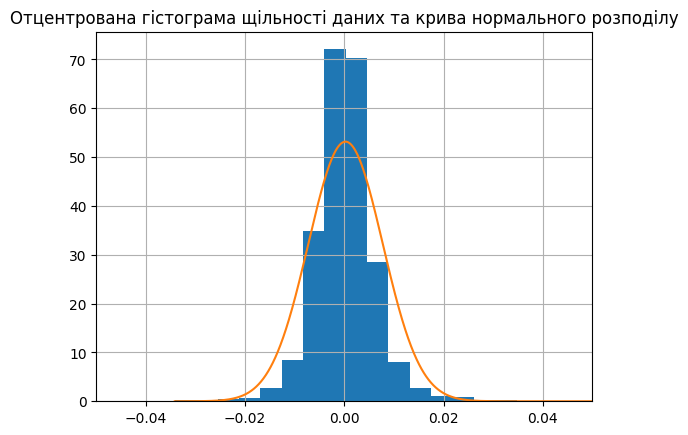

In [231]:
plt.hist(data["returns"], bins=60, density=True)
plt.plot(x, normalized_data_example)
plt.title("Отцентрована гістограма щільності даних та крива нормального розподілу")
plt.xlim(-0.05, 0.05)
plt.grid(True)

#### Перевірте дані на наявність автокореляції та кластеризації волатильності.

Для виявлення автокореляції залишок використаємо графічний та аналітичний методи.

In [232]:
test_result = acorr_ljungbox(returns,  return_df=True)
test_result

,lb_stat,lb_pvalue
1,0.809329,0.368319
2,2.804361,0.246060
3,2.985797,0.393820
4,3.280343,0.512053
5,3.726972,0.589355
6,5.552512,0.475133
7,6.049787,0.533948
8,6.076872,0.638621
9,6.303758,0.709174
10,6.378824,0.782496


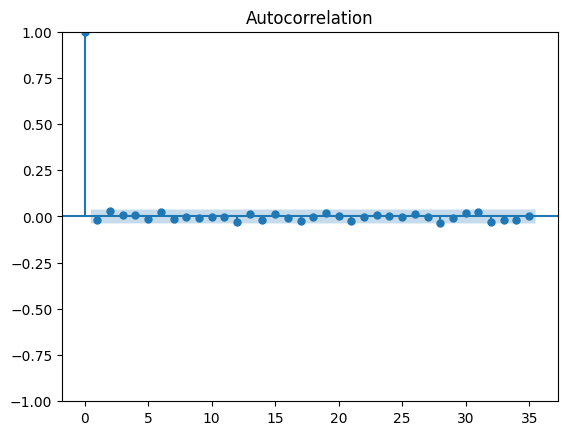

In [233]:
plot_acf(returns)
plt.show()

Всі p_value лагів теста Льюнг-Бокса більше ніж 0.05, тому автокореляції нема. Це також можно побачити, побудувавши корелограмму, де дані залежать тільки від себе.

Тепер перевіримо кластеризацію волатильності аналогічно, тільки тепер беремо абсолютні значення.

In [234]:
test_result = acorr_ljungbox(np.abs(returns),  return_df=True)
test_result

,lb_stat,lb_pvalue
1,30.469394,3.391755e-08
2,45.530362,1.297799e-10
3,58.500980,1.228676e-12
4,74.842567,2.151370e-15
5,82.142424,2.988353e-16
6,105.637247,1.667817e-20
7,110.437311,7.451206e-21
8,114.147792,5.337085e-21
9,119.697992,1.540549e-21
10,123.177980,1.144725e-21


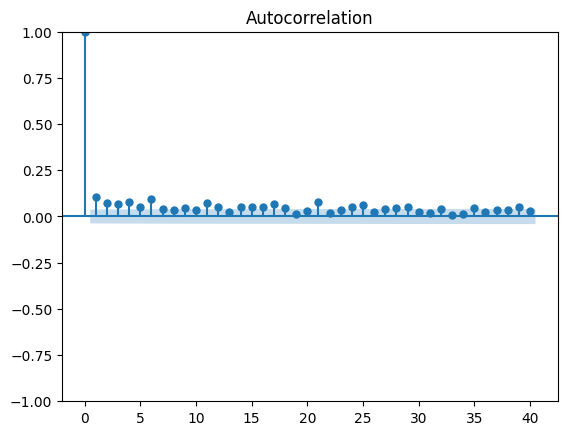

In [235]:
plot_acf(np.abs(returns), lags=40)
plt.show()

### 2. Моделювання (порівняння підходів)

#### Історичний метод (Historical Simulation)

Розглянемо декілька варіантів історичних методів: классичний, boostrap, age-weighted. Вдохновився [статею](https://medium.com/@matt_84072/historical-simulation-value-at-risk-explained-with-python-code-a904d848d146).

In [236]:
def VaR_99(data):
 """
 data - np.array of returns for 10 days
 """
 return np.percentile(data, 1, method='lower')

In [237]:
returns_10d = returns.rolling(10).sum().dropna()
returns_10d = np.array(returns_10d)

In [238]:
historic_var = VaR_99(returns_10d)
print(f'The historical VaR is {historic_var}')

The historical VaR is -0.041237009404002226


Для третьої моделі ми зважимо наші дані, більш актальні мають більше значення для розрахунку VaR, меньші - менше значення. Це зроблена для актуалізації, в якому моменті ми знаходимось зараз: більш волативному, чи менш.

In [239]:
def get_weights(ln, lm):
    lam = lm
    n = ln
    return [(lam**(i-1) * (1-lam))/(1-lam**n) for i in range(1, n+1)] 

def get_weighted_data(data, wts):
    weights_dict = {'Returns': data, 'Weights':wts}
    wts_returns = pd.DataFrame(weights_dict)

    sort_wts = wts_returns.sort_values(by='Returns')
    sort_wts['Cumulative'] = sort_wts.Weights.cumsum()
    return sort_wts

def VaR_99_age_weighted(data, lam=0.99):
    """
    data - np.array of returns for 10 days
    """
    wts = get_weights(len(data), lam)
    returns_recent_first = data[::-1]
    sort_wts = get_weighted_data(returns_recent_first, wts)

    sort_wts = sort_wts.reset_index().drop(columns=['index'])
    index = sort_wts[sort_wts.Cumulative <= 0.01].Returns.idxmax()

    xp = sort_wts.loc[index-1:index, 'Cumulative'].values
    fp = sort_wts.loc[index-1:index, 'Returns'].values
    return np.interp(0.01, xp, fp) #numpy’s standard linear interpolation

In [240]:
VaR_weighted = VaR_99_age_weighted(returns_10d)
print(f'Age-weighted VaR is {VaR_weighted}')

Age-weighted VaR is -0.018373171141821076


Бачимо, що різниця результатів між першою та останіми двома моделями велика. Це можна пояснити через особливості моделей: у класичній моделі старі хвости мают таку саму вагу, як і нові - це враховує остання модель з вагами, а модель boostrap хвости усереднює. Тому значення останіх двох меньші ніж у першої моделі.

#### Параметричний метод (Variance-Covariance)

Припускаючи нормальний розподіл

In [241]:
def VaR_99_Variance(data):
    """
    data - np.array of returns
    """
    mu_10 = 10*data.mean()
    sigma_10 = np.sqrt(10)*data.std()
    Z = 2.33 
    return -Z * sigma_10 + mu_10

In [242]:
VaR_VC = VaR_99_Variance(returns)
print(f'Variance-Covariance VaR is {VaR_VC}')

Variance-Covariance VaR is -0.052844509267711476


Бачимо, що цей результат цього методу дуже схожий на результат класичного історичного методу.

#### GARCH-моделювання

Домножаємо дані на 100 для того, щоб не було проблем при навчані моделі. Spoiler: це було проблемою на третьому етапі, при валідації. Тому домноження не є проблемою, просто при рахувані VaR, значення поділимо на 100.

In [243]:
model = arch_model(returns*100, vol='GARCH', p=1, q=1, dist='normal')
res = model.fit()
print(res.summary())

Iteration:      1,   Func. Count:      6,   Neg. LLF: 23193.958579129234
Iteration:      2,   Func. Count:     17,   Neg. LLF: 7079.819373184854
Iteration:      3,   Func. Count:     26,   Neg. LLF: 3434.6460237481306
Iteration:      4,   Func. Count:     32,   Neg. LLF: 2711.4389443467553
Iteration:      5,   Func. Count:     37,   Neg. LLF: 4189.495098123372
Iteration:      6,   Func. Count:     44,   Neg. LLF: 2708.338872844635
Iteration:      7,   Func. Count:     49,   Neg. LLF: 2708.0163216783017
Iteration:      8,   Func. Count:     54,   Neg. LLF: 2707.9967698331925
Iteration:      9,   Func. Count:     59,   Neg. LLF: 2707.9941683614
Iteration:     10,   Func. Count:     64,   Neg. LLF: 2707.9941662198917
Iteration:     11,   Func. Count:     68,   Neg. LLF: 2707.9941630316707
Optimization terminated successfully    (Exit mode 0)
            Current function value: 2707.9941662198917
            Iterations: 11
            Function evaluations: 68
            Gradient evaluatio

In [244]:
fc = res.forecast(horizon=10, reindex=False)

mu_10 = fc.mean.iloc[-1].values.sum()
sigma_10 = fc.variance.iloc[-1].values.sum()

VaR_GARCH = (mu_10  + norm.ppf(0.01) * np.sqrt(sigma_10))/100

print(f"GARCH VaR: {VaR_GARCH}")

GARCH VaR: -0.064002185973629


In [245]:
lb = acorr_ljungbox(res.resid, return_df=True)
print(lb)

     lb_stat  lb_pvalue
1   0.809329   0.368319
2   2.804361   0.246060
3   2.985797   0.393820
4   3.280343   0.512053
5   3.726972   0.589355
6   5.552512   0.475133
7   6.049787   0.533948
8   6.076872   0.638621
9   6.303758   0.709174
10  6.378824   0.782496


GARCH показав найменший результат порівнюючи з іншими моделями. Всі p_value лагів теста лишків Льюнг-Бокса більше ніж 0.05, тому автокореляції нема, модель адекватна.

### 3. Валідація (Backtesting):

#### Проведіть бектестінг обраних моделей на останньому році даних.

In [246]:
models_10d_ret = [VaR_99, VaR_99_age_weighted]
model_ret = [VaR_99_Variance]
models_results = dict()

In [247]:
TEST_DAYS = 750

In [248]:
test = np.array(returns_10d[-TEST_DAYS:])

In [249]:
def validate_VaR(models, returns):
    for model in models:
        current_model_results = list()
        current_model_exceptions = list()
        print("Current model:", model.__name__)
        for inc_day in range(TEST_DAYS, 0, -1):
            prediction = model(returns[:-inc_day])
            current_model_results.append(prediction)
        current_model_exceptions = test < current_model_results
        violation_rate = np.sum(current_model_exceptions)
        models_results[model.__name__] = (current_model_results, current_model_exceptions, violation_rate)   

In [250]:
validate_VaR(models_10d_ret, returns_10d)
validate_VaR(model_ret, returns)

Current model: VaR_99
Current model: VaR_99_age_weighted


Current model: VaR_99_Variance


In [251]:
current_model_results = list()
current_model_exceptions = list()
for inc_day in range(TEST_DAYS, 0, -1):
    model = arch_model(100*returns[:-inc_day], vol='GARCH', p=1, o=0, q=1, dist='normal')
    
    res = model.fit(disp='off')
    fc = res.forecast(horizon=10, reindex=False)
    
    mu_10 = fc.mean.iloc[-1].values.sum()
    sigma_10 = fc.variance.iloc[-1].values.sum()
    prediction = (mu_10+norm.ppf(0.01) * np.sqrt(sigma_10))/100
    
    current_model_results.append(prediction)

current_model_exceptions = test < current_model_results
violation_rate = np.sum(current_model_exceptions)
models_results["VaR_99_GARCH"] = (current_model_results, current_model_exceptions, violation_rate)   

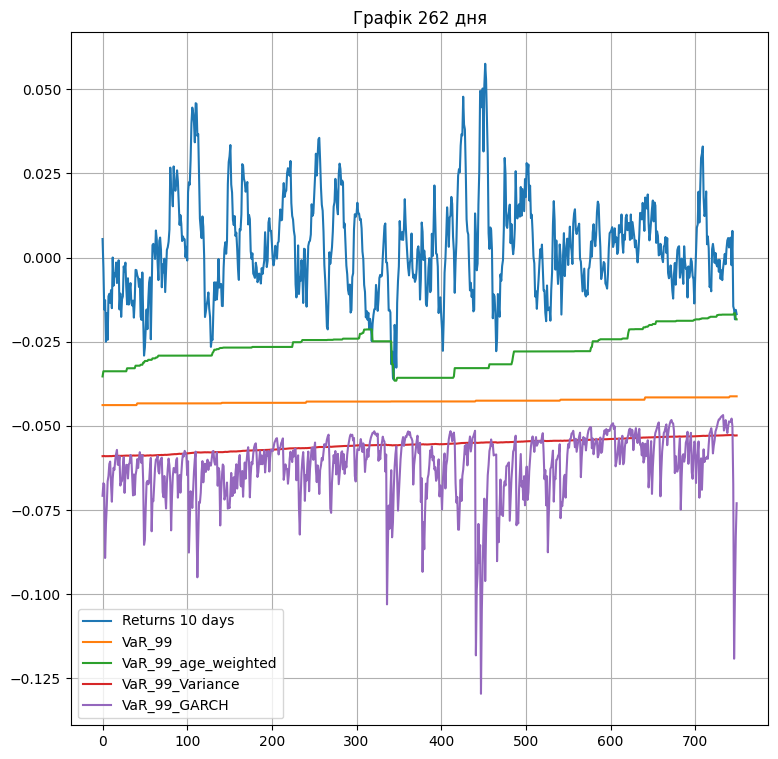

In [252]:
plt.figure(figsize=(9, 9))
plot_graph(test, label="Returns 10 days")
for model_name in models_results:
    plot_graph(models_results[model_name][0], label=model_name)
plt.title("Графік 262 дня")
plt.legend()

#### Порахуйте кількість «пробоїв» (випадків, коли реальний збиток перевищив прогнозний VaR).

<BarContainer object of 4 artists>

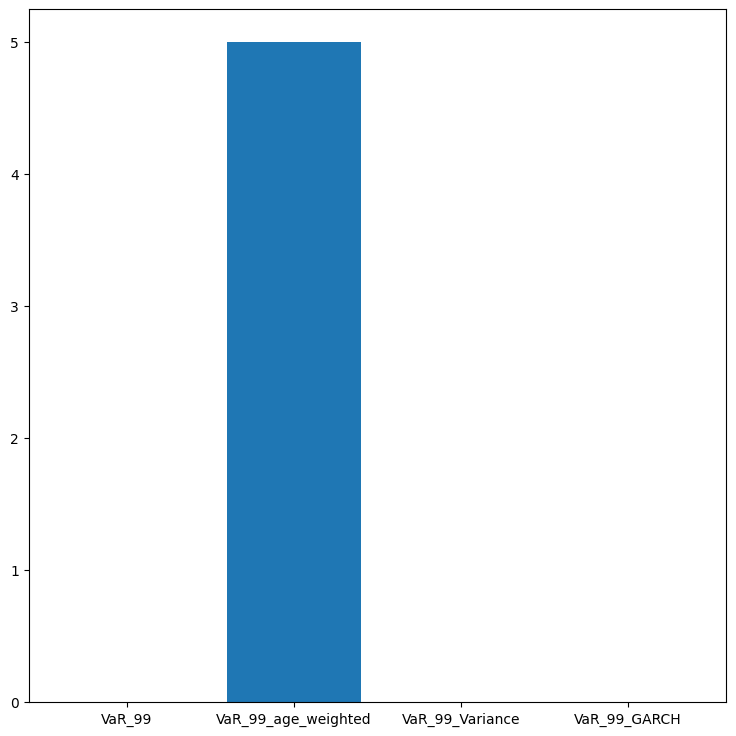

In [253]:
violation_rates = [models_results[model_name][2] for model_name in models_results]
model_names = [model_name for model_name in models_results]
plt.figure(figsize=(9, 9))
plt.bar(model_names, violation_rates)

### Binomial test

In [254]:
from scipy.stats import binomtest, binom

In [255]:
def varbinomtest(violation_rates, N=250, VaR_level=0.99, test_level = 0.95):
    """Validate binomial test for VaR_alpha

    Args:
        violation_rates: integer or array numbers of exceptions 
        N (int, optional): Number of observations for test validation. Defaults to 366.
        VaR_level (float, optional): Confidence level of VaR. Defaults to 0.99.
        test_level (float, optional): Confidence level of Test. Defaults to 0.95.

    Returns:
        dict: Results of validation.
    """
    signification_level = 1-test_level
    p = 1-VaR_level
    
    p_values = np.array([binomtest(k=violation_rate, n=N, p=p, alternative="two-sided").pvalue for violation_rate in violation_rates])
        
    results = {    
        "Observations": N,
        "Failures": violation_rates,
        "Expected in average": N * p,
        "PValues": p_values,
        "Decision": p_values > signification_level
    }
    return results

In [256]:
varbinomtest(violation_rates, TEST_DAYS)

{'Observations': 750,
 'Failures': [np.int64(0), np.int64(5), np.int64(0), np.int64(0)],
 'Expected in average': 7.500000000000007,
 'PValues': array([0.00126827, 0.46278976, 0.00126827, 0.00126827]),
 'Decision': array([False,  True, False, False])}

### Traffic Light Test

In [257]:
def get_multiplier(zone, var_level, observed_confidence):
        if zone == "green":
            increase = 0.0
        elif zone == "red":
            increase = 1.0
        else:
            # increase = (-np.log10(type_i)-1)/3
            # increase = max(0.0, min(1.0, increase))

            z_assumed = norm.ppf(var_level)
            z_observed = norm.ppf(observed_confidence)
            increase = 1.0  if not np.isfinite(z_observed) or z_observed <= 0 else 3.0 * ((z_assumed / z_observed) - 1.0)

        multiplier = np.round(3.0 + increase, 4)
    
        return multiplier

def trafficlight_test(violation_rates, N=250, VaR_level=0.99):
    """Validate traffic light test for VaR_alpha and estimate multiplier.

        Args:
            violation_rates: integer or array numbers of exceptions 
            N (int, optional): Number of observations for test validation. Defaults to 366.
            VaR_level (float, optional): Confidence level of VaR. Defaults to 0.99.

        Returns:
            dict: Results of validation.
    """
    p = 1 - VaR_level
    probability = []
    type_i = []
    zone = []
    multiplier = []
    for violation_rate in violation_rates:
        probability.append(binom.cdf(k=violation_rate, n=N, p=p))
        type_i.append(1-probability[-1])
        zone.append('green' if probability[-1] <= 0.95 else 'yellow' if probability[-1] <= 0.9999 else 'red')
        multiplier.append(get_multiplier(zone[-1], VaR_level, 1-violation_rate/N))
        
    results = {
        "Observations": N,
        "Failures": violation_rates,
        "Probability": probability,
        "Zone": zone,
        "TypeI": type_i,
        "Multiplier": multiplier
    }
    return results


In [258]:
trafficlight_test(violation_rates, TEST_DAYS)

{'Observations': 750,
 'Failures': [np.int64(0), np.int64(5), np.int64(0), np.int64(0)],
 'Probability': [np.float64(0.0005325936058869026),
  np.float64(0.24006281456801237),
  np.float64(0.0005325936058869026),
  np.float64(0.0005325936058869026)],
 'Zone': ['green', 'green', 'green', 'green'],
 'TypeI': [np.float64(0.9994674063941131),
  np.float64(0.7599371854319876),
  np.float64(0.9994674063941131),
  np.float64(0.9994674063941131)],
 'Multiplier': [np.float64(3.0),
  np.float64(3.0),
  np.float64(3.0),
  np.float64(3.0)]}

### Kupiec POF Test

In [259]:
def pof_test(violation_rates, N=250, VaR_level=0.99, test_level=0.95):
    """Validate POF test for VaR_alpha.

    Args:
        violation_rates: integer or array numbers of exceptions 
        N (int, optional): Number of observations for test validation. Defaults to 366.
        VaR_level (float, optional): Confidence level of VaR. Defaults to 0.99.

    Returns:
        dict: Results of validation.
    """
    violation_rates = np.array(violation_rates)

    significance_level = 1.0 - test_level
    tprobabilty = 1-VaR_level
    tprobabilities_observed = violation_rates/N

    l0 = xlogy(violation_rates, tprobabilty)  +  xlogy((N-violation_rates), (1.-tprobabilty))
    l1 = xlogy(violation_rates, tprobabilities_observed)  +  xlogy((N-violation_rates), (1.-tprobabilities_observed))
    lr = -2.0 * (l0-l1)


    p_values = chi2.sf(lr, df=1)

    results = {
        "Observations": N,
        "Failures": violation_rates,
        "TailProbability": tprobabilty,
        "ObservedTailProbability": tprobabilities_observed,
        "POF": lr,
        "PValues": p_values,
        "Decision": p_values > significance_level
    }

    return results

In [260]:
pof_test(violation_rates, TEST_DAYS)

{'Observations': 750,
 'Failures': array([0, 5, 0, 0]),
 'TailProbability': 0.010000000000000009,
 'ObservedTailProbability': array([0.        , 0.00666667, 0.        , 0.        ]),
 'POF': array([15.07550378,  0.953757  , 15.07550378, 15.07550378]),
 'PValues': array([1.03295080e-04, 3.28764826e-01, 1.03295080e-04, 1.03295080e-04]),
 'Decision': array([False,  True, False, False])}

### IF Test

In [261]:
exceptions = np.array([models_results[model_name][1] for model_name in models_results])

In [262]:
def get_freqeuencies(I):
    if I.ndim == 1:
        prev = I[:-1]
        curr = I[1:]
        axis = 0

    else:
        prev = I[:, :-1]
        curr = I[:, 1:]
        axis = 1

    n00 = np.sum((prev == 0) & (curr == 0), axis=axis)
    n01 = np.sum((prev == 0) & (curr == 1), axis=axis)
    n10 = np.sum((prev == 1) & (curr == 0), axis=axis)
    n11 = np.sum((prev == 1) & (curr == 1), axis=axis)

    return n00, n01, n10, n11

In [263]:
def if_test(exceptions, N=250, test_level=0.95):
    significance_level = 1 - test_level
    n00, n01, n10, n11 = get_freqeuencies(exceptions)
    
    p0 = np.divide(n01, n00 + n01, out=np.zeros_like(n00, dtype=float),where=(n00 + n01) > 0)
    p1 = np.divide(n11, n10 + n11, out=np.zeros_like(n11, dtype=float), where=(n10 + n11) > 0)
    p = (n01+n11)/(n00+n01+n10+n11)

    ll0 = xlogy(n00 + n10, 1 - p) + xlogy(n01 + n11, p)
    ll1 = xlogy(n00, 1 - p0) + xlogy(n01, p0) + xlogy(n10, 1 - p1) + xlogy(n11, p1)
    

    ift = -2 * (ll0 - ll1)
    p_values = chi2.sf(ift, df=1)
    
    results = {
        "Observations": N,
        "p0": p0,
        "p1": p1,
        "p": p,
        "IF": ift,
        "PValues": p_values,
        "Decision": p_values > significance_level
    }

    return results

In [264]:
if_test(exceptions, TEST_DAYS)

{'Observations': 750,
 'p0': array([0.        , 0.00537634, 0.        , 0.        ]),
 'p1': array([0. , 0.2, 0. , 0. ]),
 'p': array([0.        , 0.00667557, 0.        , 0.        ]),
 'IF': array([-0.        ,  5.27110475, -0.        , -0.        ]),
 'PValues': array([1.        , 0.02168225, 1.        , 1.        ]),
 'Decision': array([ True, False,  True,  True])}